<a href="https://colab.research.google.com/github/OJB-Quantum/MuMax3-How-To/blob/main/Python%20Code_MuMax3%20Data%20Plots/STT_Switching_Simulation_with_MuMax3_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

The following table defines the foundational parameters alongside their required SI units for the MuMax3 execution.

| Physical Parameter | Script Variable | Standard SI Unit | Unit Symbol |
| --- | --- | --- | --- |
| Spatial dimension | `sizeX`, `sizeY`, `sizeZ` | meters | m |
| Grid discretization | `Nx`, `Ny` | dimensionless | $N_x, N_y$ |
| Volume saturation magnetization | `Msat` | amperes per meter | A/m |
| Exchange stiffness constant | `Aex` | joules per meter | J/m |
| Gilbert damping constant | `alpha` | dimensionless | $\alpha$ |
| Normalized initial magnetization | `m` | dimensionless | $\mathbf{m}$ |
| Slonczewski asymmetry parameter | `lambda` | dimensionless | $\Lambda$ |
| Spin polarization fraction | `Pol` | dimensionless | $P$ |
| Secondary Slonczewski parameter | `epsilonprime` | dimensionless | $\epsilon'$ |
| In-plane geometrical angle | `angle` | degrees | ° |
| Fixed layer polarization vector | `fixedlayer`, `px`, `py` | dimensionless | $\mathbf{p}$ |
| Total electrical current | `Jtot` | amperes | A |
| Cross-sectional area | `area` | square meters | m² |
| Electrical current density | `jc`, `J` | amperes per square meter | A/m² |
| Integration time periods | `autosave`, `tableautosave`, `run` | seconds | s |

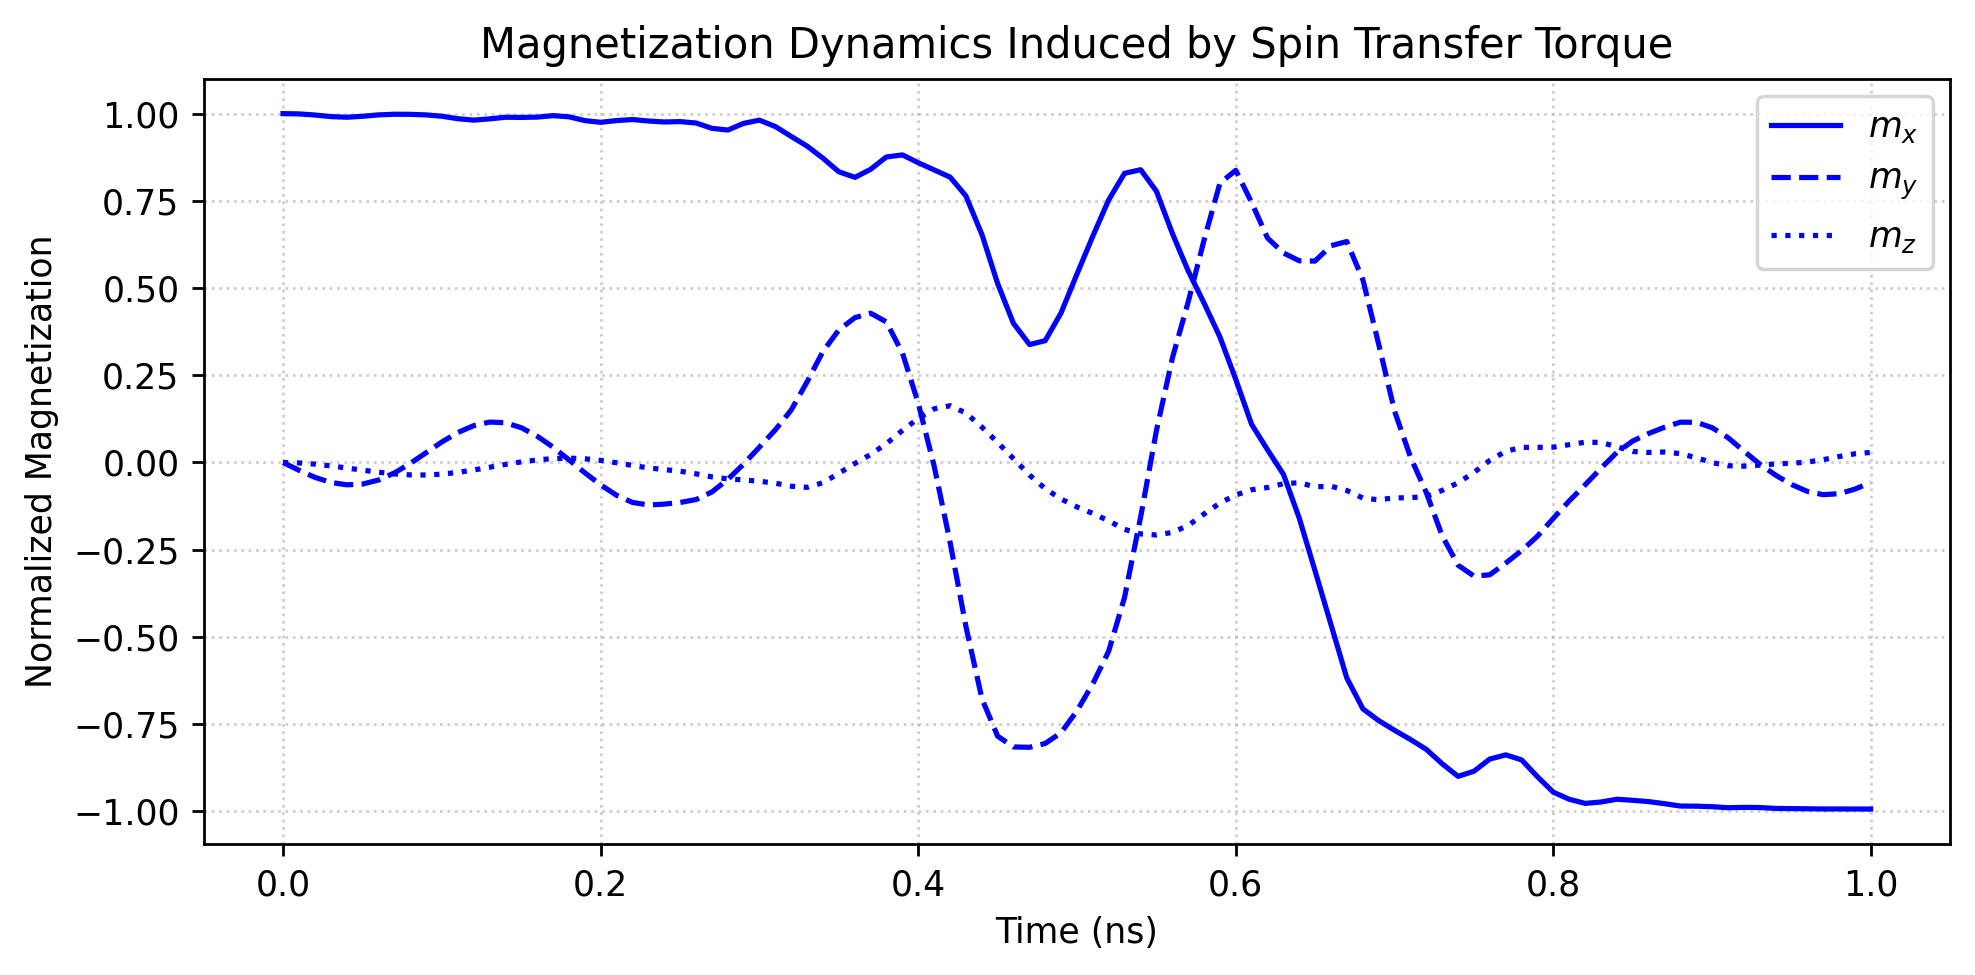

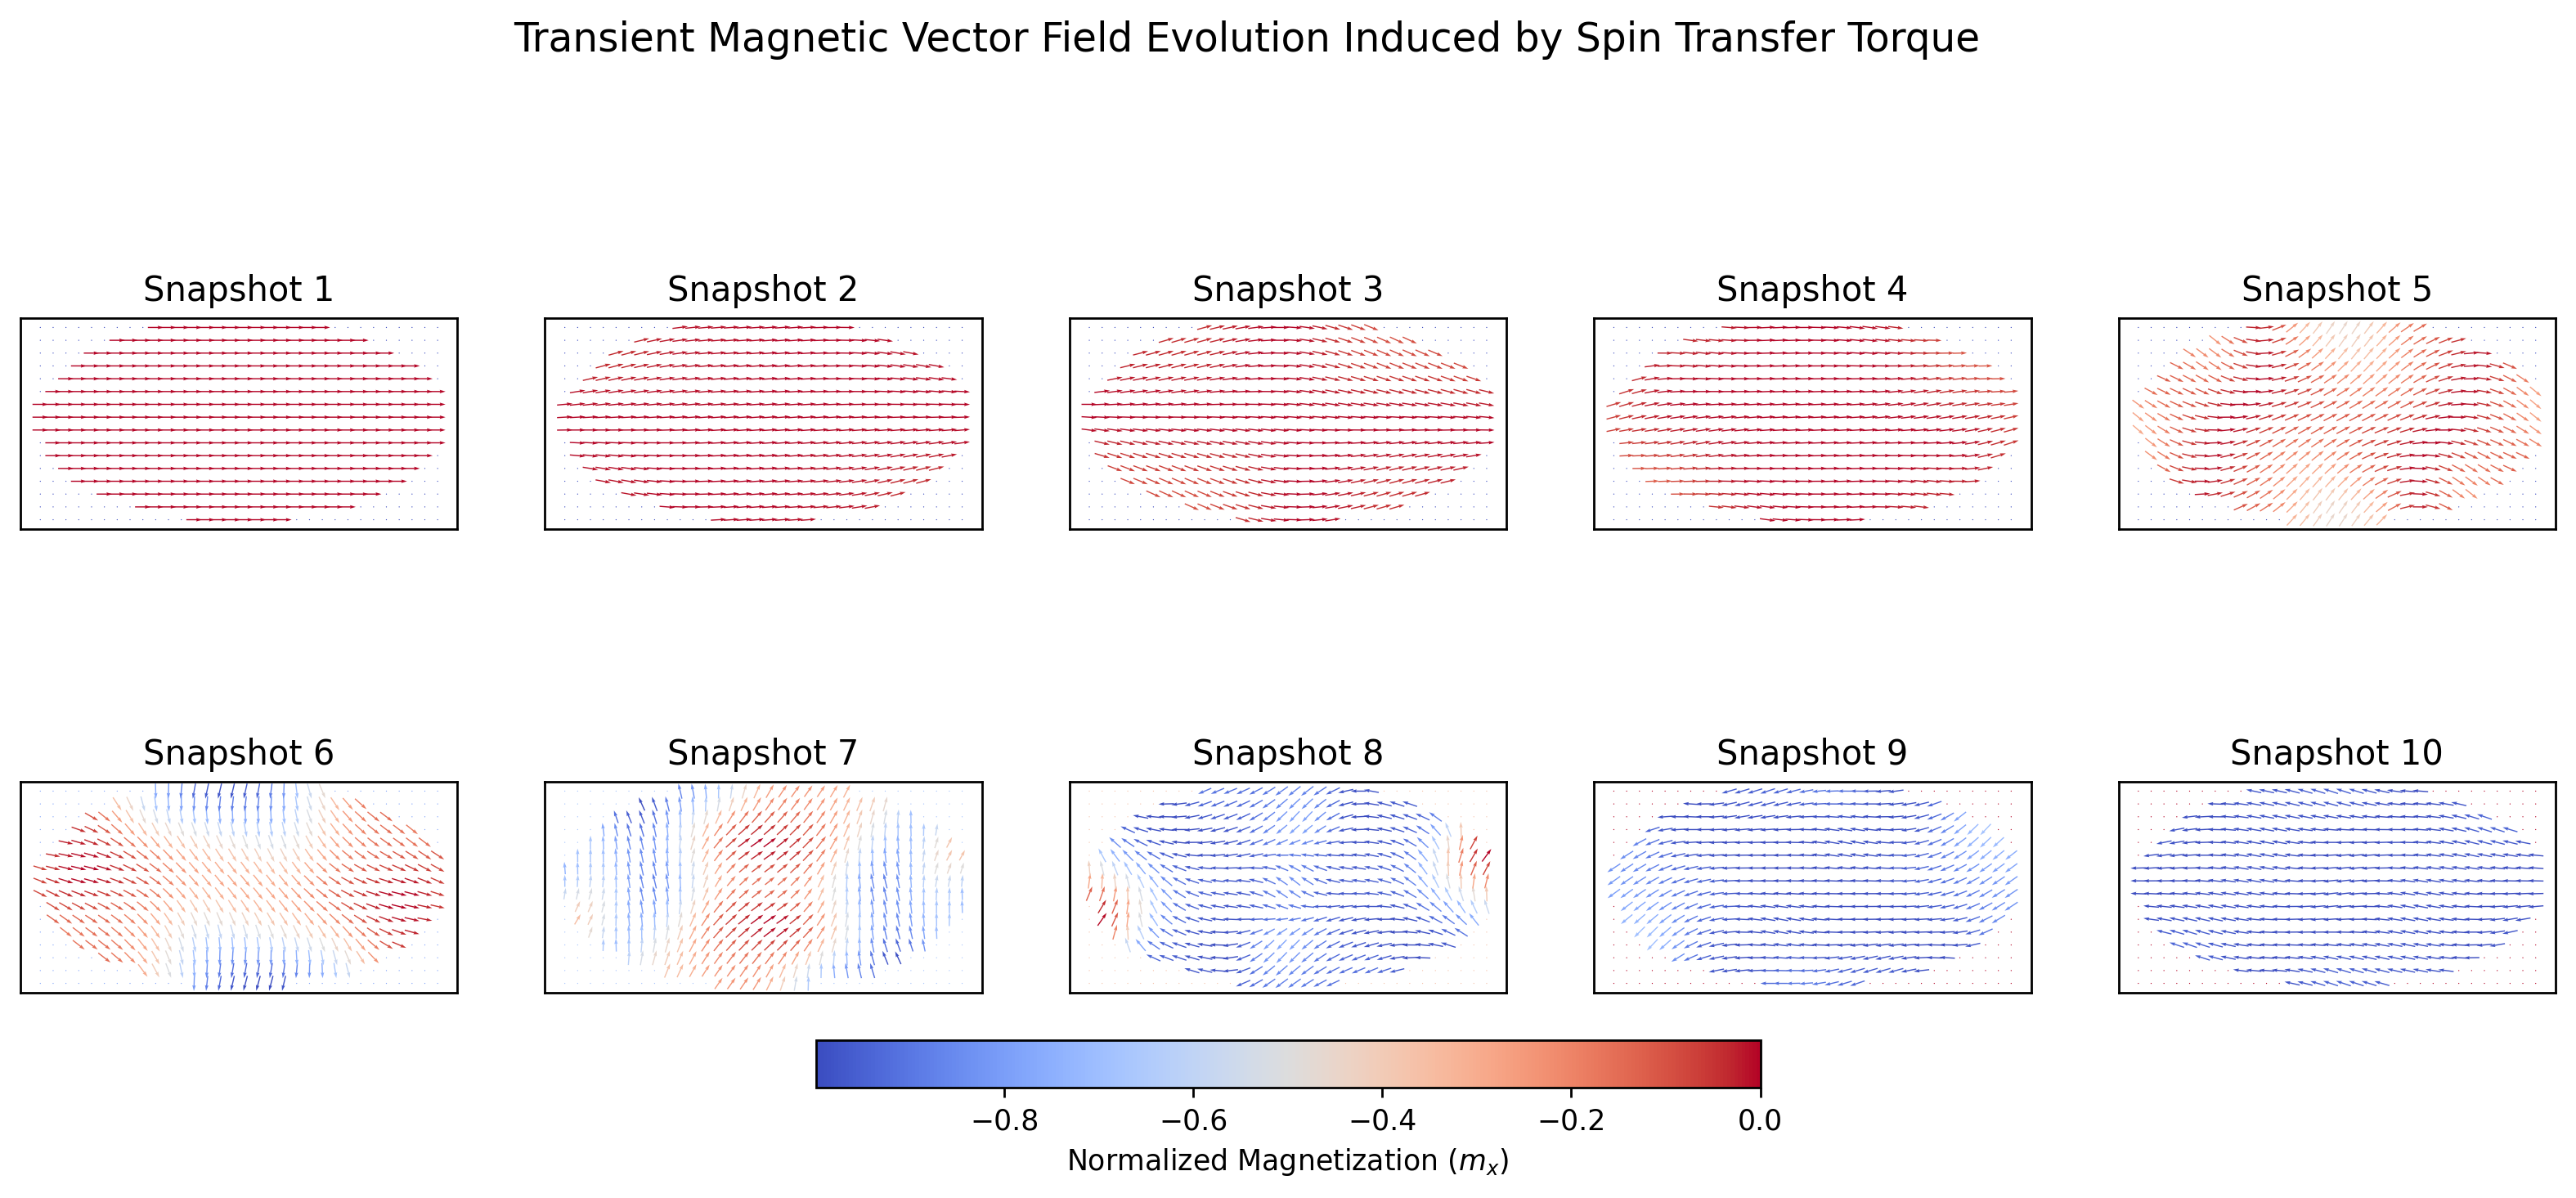

In [ ]:
"""This script initializes the MuMax3 micromagnetic simulation environment, executes the numerical
integration, extracts the resulting magnetic vector fields, and visualizes the transient dynamics
alongside ten distinct spatial snapshots within a single unified process. The initial example material
used here is a permalloy free layer.
"""

import os
import subprocess
import sys
import glob

# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------
MUMAX_URL = "https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz"
ARCHIVE_NAME = "mumax3.12_linux_cuda12.9.tar.gz"
EXTRACTED_DIR = "mumax3.12_linux_cuda12.9"
TARGET_DIR = "mumax3.12"
SIMULATION_FILENAME = "stt_bit_cell.mx3"
RESULTS_DIRECTORY = "stt_bit_cell.out"
TABULAR_DATA_FILE = "table.txt"
FIGURE_RESOLUTION_DPI = 250
FONT_FAMILY_PREFERENCE = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT_PREFERENCE = 'normal'
SNAPSHOT_ROWS = 2
SNAPSHOT_COLUMNS = 5
MAX_SNAPSHOTS = 10
QUIVER_SUBSAMPLING_STEP = 2
QUIVER_ARROW_SCALE = 28.0
MAGNETIZATION_COLOR_DIRECTION = "M_X"  # Accepted variables: "M_X", "M_Y", or "M_Z"

# ---------------------------------------------------
# Environment Preparation
# ---------------------------------------------------
subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version,compute_cap", "--format=csv"], check=True)
subprocess.run(["wget", "-q", MUMAX_URL], check=True)
subprocess.run(["tar", "-xvf", ARCHIVE_NAME], check=True)

if os.path.exists(ARCHIVE_NAME):
    os.remove(ARCHIVE_NAME)

if os.path.exists(TARGET_DIR):
    subprocess.run(["rm", "-rf", TARGET_DIR], check=True)

os.rename(EXTRACTED_DIR, TARGET_DIR)
os.environ["PATH"] += f":/content/{TARGET_DIR}"

# ---------------------------------------------------
# Simulation Configuration
# ---------------------------------------------------

'''The below parameters are for Permalloy (NiFe).
However, you can change the free layer terms to match the parameters of an existing magnetic tunnel junction (MTJ) free layer
or an existing spin torque oscillator (STO) free layer material you might be interested in, which are often found in published
articles or lectures. Keep in mind that MuMax3 defaults to using SI units.
'''

mx3_configuration = """
// geometry
sizeX := 160e-9
sizeY := 80e-9
sizeZ := 5e-9

Nx := 64
Ny := 32

setgridsize(Nx, Ny, 1)
setcellsize(sizeX/Nx, sizeY/Ny, sizeZ)
setGeom(ellipse(sizeX, sizeY))

// set up free layer
Msat  = 800e3 // This is the same thing as 8.0e5
Aex   = 13e-12
alpha = 0.01
m     = uniform(1, 0, 0)

// set up spacer layer parameters
lambda       = 1
Pol          = 0.5669
epsilonprime = 0

// set up fixed layer polarization
angle := 20
px := cos(angle * pi/180)
py := sin(angle * pi/180)
fixedlayer = vector(px, py, 0)

// send current or switching current for STT MTJs
Jtot := -0.008            // total current in A
area := sizeX*sizeY*pi/4
jc   := Jtot / area       // current density in A/m2
J = vector(0, 0, jc)

// schedule output & run
autosave(m, 100e-12)
tableautosave(10e-12)
run(1e-9)
"""

with open(SIMULATION_FILENAME, "w", encoding="utf-8") as file:
    file.write(mx3_configuration)

# ---------------------------------------------------
# Numerical Execution
# ---------------------------------------------------
subprocess.run(["mumax3", SIMULATION_FILENAME], check=True)

# ---------------------------------------------------
# Package Verification
# ---------------------------------------------------
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "matplotlib", "numpy"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Matplotlib Parameters
# ---------------------------------------------------
plt.rcParams['figure.dpi'] = FIGURE_RESOLUTION_DPI
plt.rcParams['font.sans-serif'] = FONT_FAMILY_PREFERENCE
plt.rcParams['font.weight'] = FONT_WEIGHT_PREFERENCE

# ---------------------------------------------------
# Tabular Data Ingestion and Visualization
# ---------------------------------------------------
data_path = os.path.join(RESULTS_DIRECTORY, TABULAR_DATA_FILE)
simulation_data = pd.read_csv(data_path, sep='\t')

time_array = simulation_data['# t (s)'] * 1e9
mx_component = simulation_data['mx ()']
my_component = simulation_data['my ()']
mz_component = simulation_data['mz ()']

fig_timeseries, ax_timeseries = plt.subplots(figsize=(8, 4))
ax_timeseries.plot(time_array, mx_component, label=r'$m_x$', color='#0000FF', linestyle='solid', linewidth=1.5)
ax_timeseries.plot(time_array, my_component, label=r'$m_y$', color='#0000FF', linestyle='dashed', linewidth=1.5)
ax_timeseries.plot(time_array, mz_component, label=r'$m_z$', color='#0000FF', linestyle='dotted', linewidth=1.5)

ax_timeseries.set_xlabel('Time (ns)')
ax_timeseries.set_ylabel('Normalized Magnetization')
ax_timeseries.set_title('Magnetization Dynamics Induced by Spin Transfer Torque')
ax_timeseries.legend(loc='upper right', frameon=True)
ax_timeseries.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Vector Field Conversion and Ingestion
# ---------------------------------------------------
ovf_files = sorted(glob.glob(os.path.join(RESULTS_DIRECTORY, "*.ovf")))
ovf_files = ovf_files[:MAX_SNAPSHOTS]

for ovf_file in ovf_files:
    subprocess.run(["mumax3-convert", "-numpy", ovf_file], check=True)

npy_files = sorted(glob.glob(os.path.join(RESULTS_DIRECTORY, "*.npy")))
npy_files = npy_files[:MAX_SNAPSHOTS]

# ---------------------------------------------------
# Vector Field Visualization
# ---------------------------------------------------
fig_vectors, axes = plt.subplots(SNAPSHOT_ROWS, SNAPSHOT_COLUMNS, figsize=(16, 6))
axes_flat = axes.flatten()

if MAGNETIZATION_COLOR_DIRECTION == "M_X":
    colorbar_label = r'Normalized Magnetization ($m_x$)'
elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
    colorbar_label = r'Normalized Magnetization ($m_y$)'
elif MAGNETIZATION_COLOR_DIRECTION == "M_Z":
    colorbar_label = r'Normalized Magnetization ($m_z$)'
else:
    colorbar_label = r'Normalized Magnetization ($m_x$)'

for index, npy_file in enumerate(npy_files):
    vector_data = np.load(npy_file)

    mx_grid = vector_data[0, 0, :, :]
    my_grid = vector_data[1, 0, :, :]
    mz_grid = vector_data[2, 0, :, :]

    if MAGNETIZATION_COLOR_DIRECTION == "M_X":
        color_grid = mx_grid
    elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
        color_grid = my_grid
    elif MAGNETIZATION_COLOR_DIRECTION == "M_Z":
        color_grid = mz_grid
    else:
        color_grid = mx_grid

    ny_points, nx_points = mx_grid.shape
    x_coordinates, y_coordinates = np.meshgrid(np.arange(nx_points), np.arange(ny_points))

    ax = axes_flat[index]

    slice_y = slice(0, ny_points, QUIVER_SUBSAMPLING_STEP)
    slice_x = slice(0, nx_points, QUIVER_SUBSAMPLING_STEP)

    quiver_plot = ax.quiver(
        x_coordinates[slice_y, slice_x],
        y_coordinates[slice_y, slice_x],
        mx_grid[slice_y, slice_x],
        my_grid[slice_y, slice_x],
        color_grid[slice_y, slice_x],
        cmap='coolwarm',
        pivot='mid',
        scale=QUIVER_ARROW_SCALE
    )

    ax.set_title(f'Snapshot {index + 1}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

cbar = fig_vectors.colorbar(quiver_plot, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.05)
cbar.set_label(colorbar_label)
fig_vectors.suptitle('Transient Magnetic Vector Field Evolution Induced by Spin Transfer Torque', fontsize=14)

plt.show()

In [1]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev

!uv pip install -q -U \
    "numpy>=2.3.5,<2.4" \
    "scipy>=1.16,<1.17" \
    pandas \
    mpi4py \
    pyfr \
    k3d \
    cupy-cuda12x \
    trimesh \
    matplotlib \
    rtree \
    embreex \
    ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 4, MHz: 2000.144
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 76c76af3bb95
//Timestamp: 2026-08-21 17:26:46
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
stt_bit_cell.mx3 : OK

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6

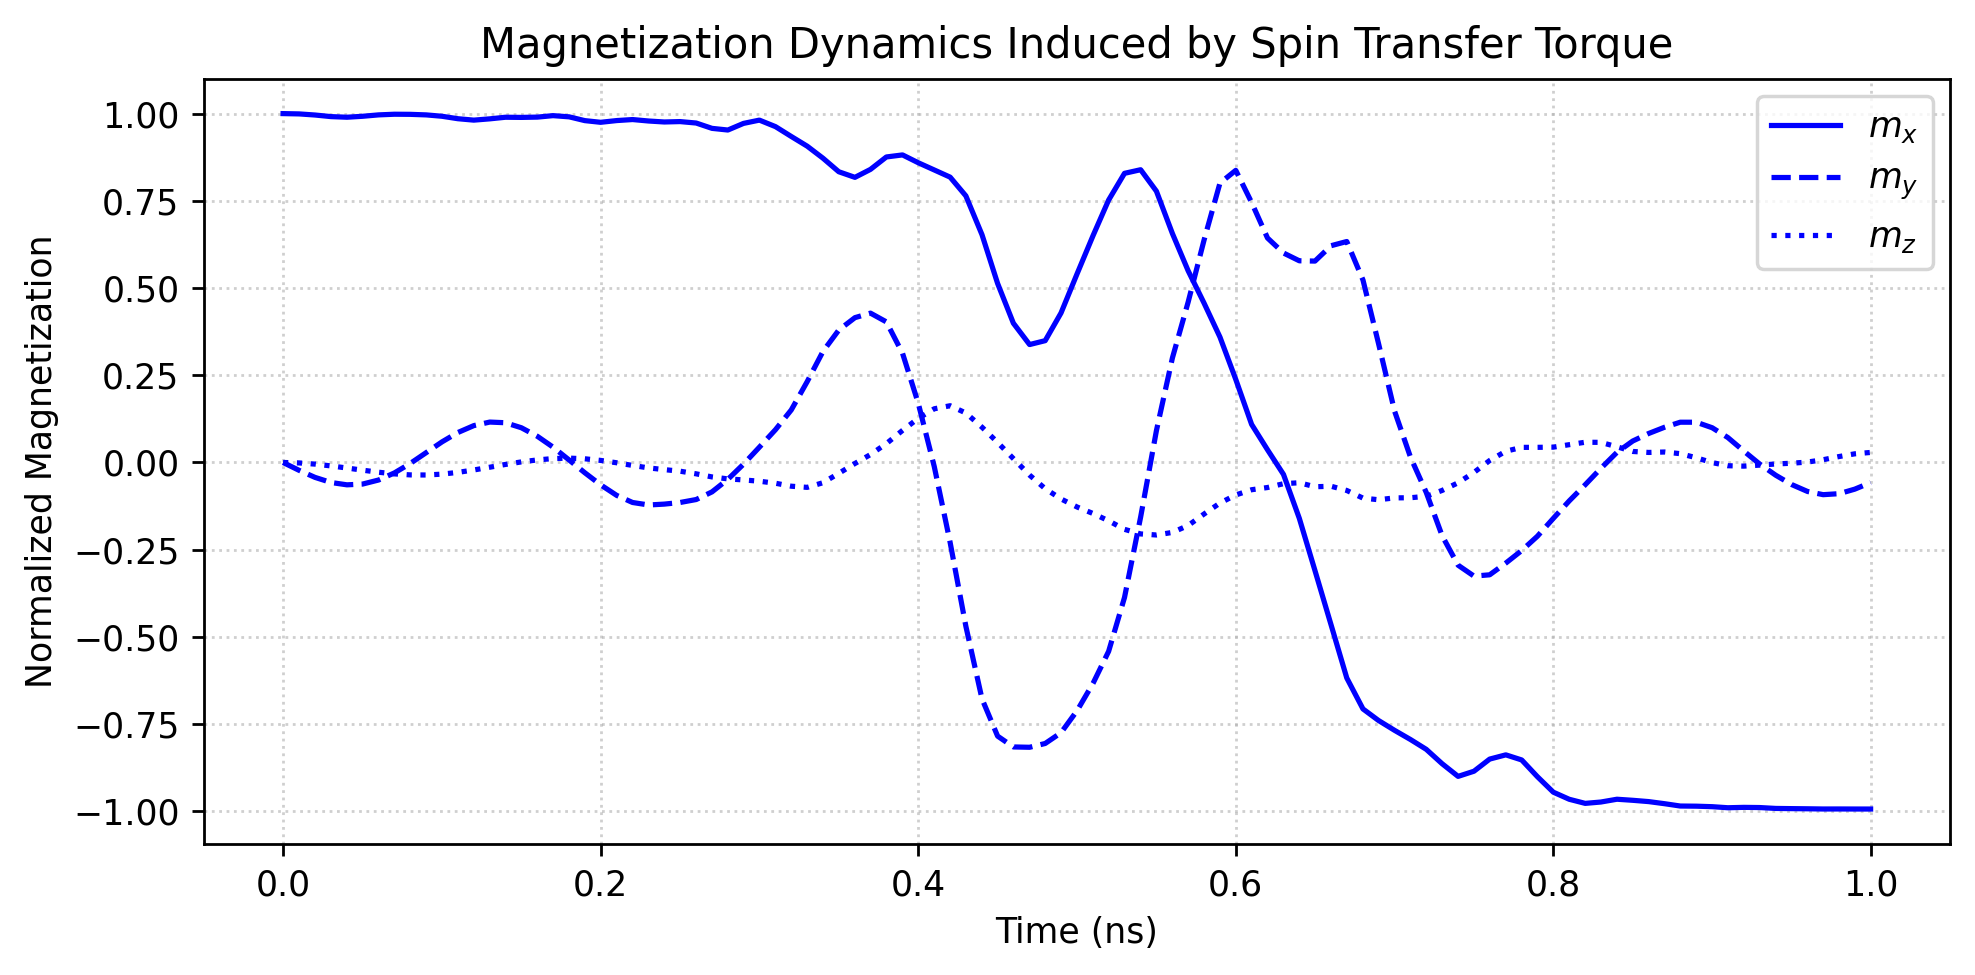

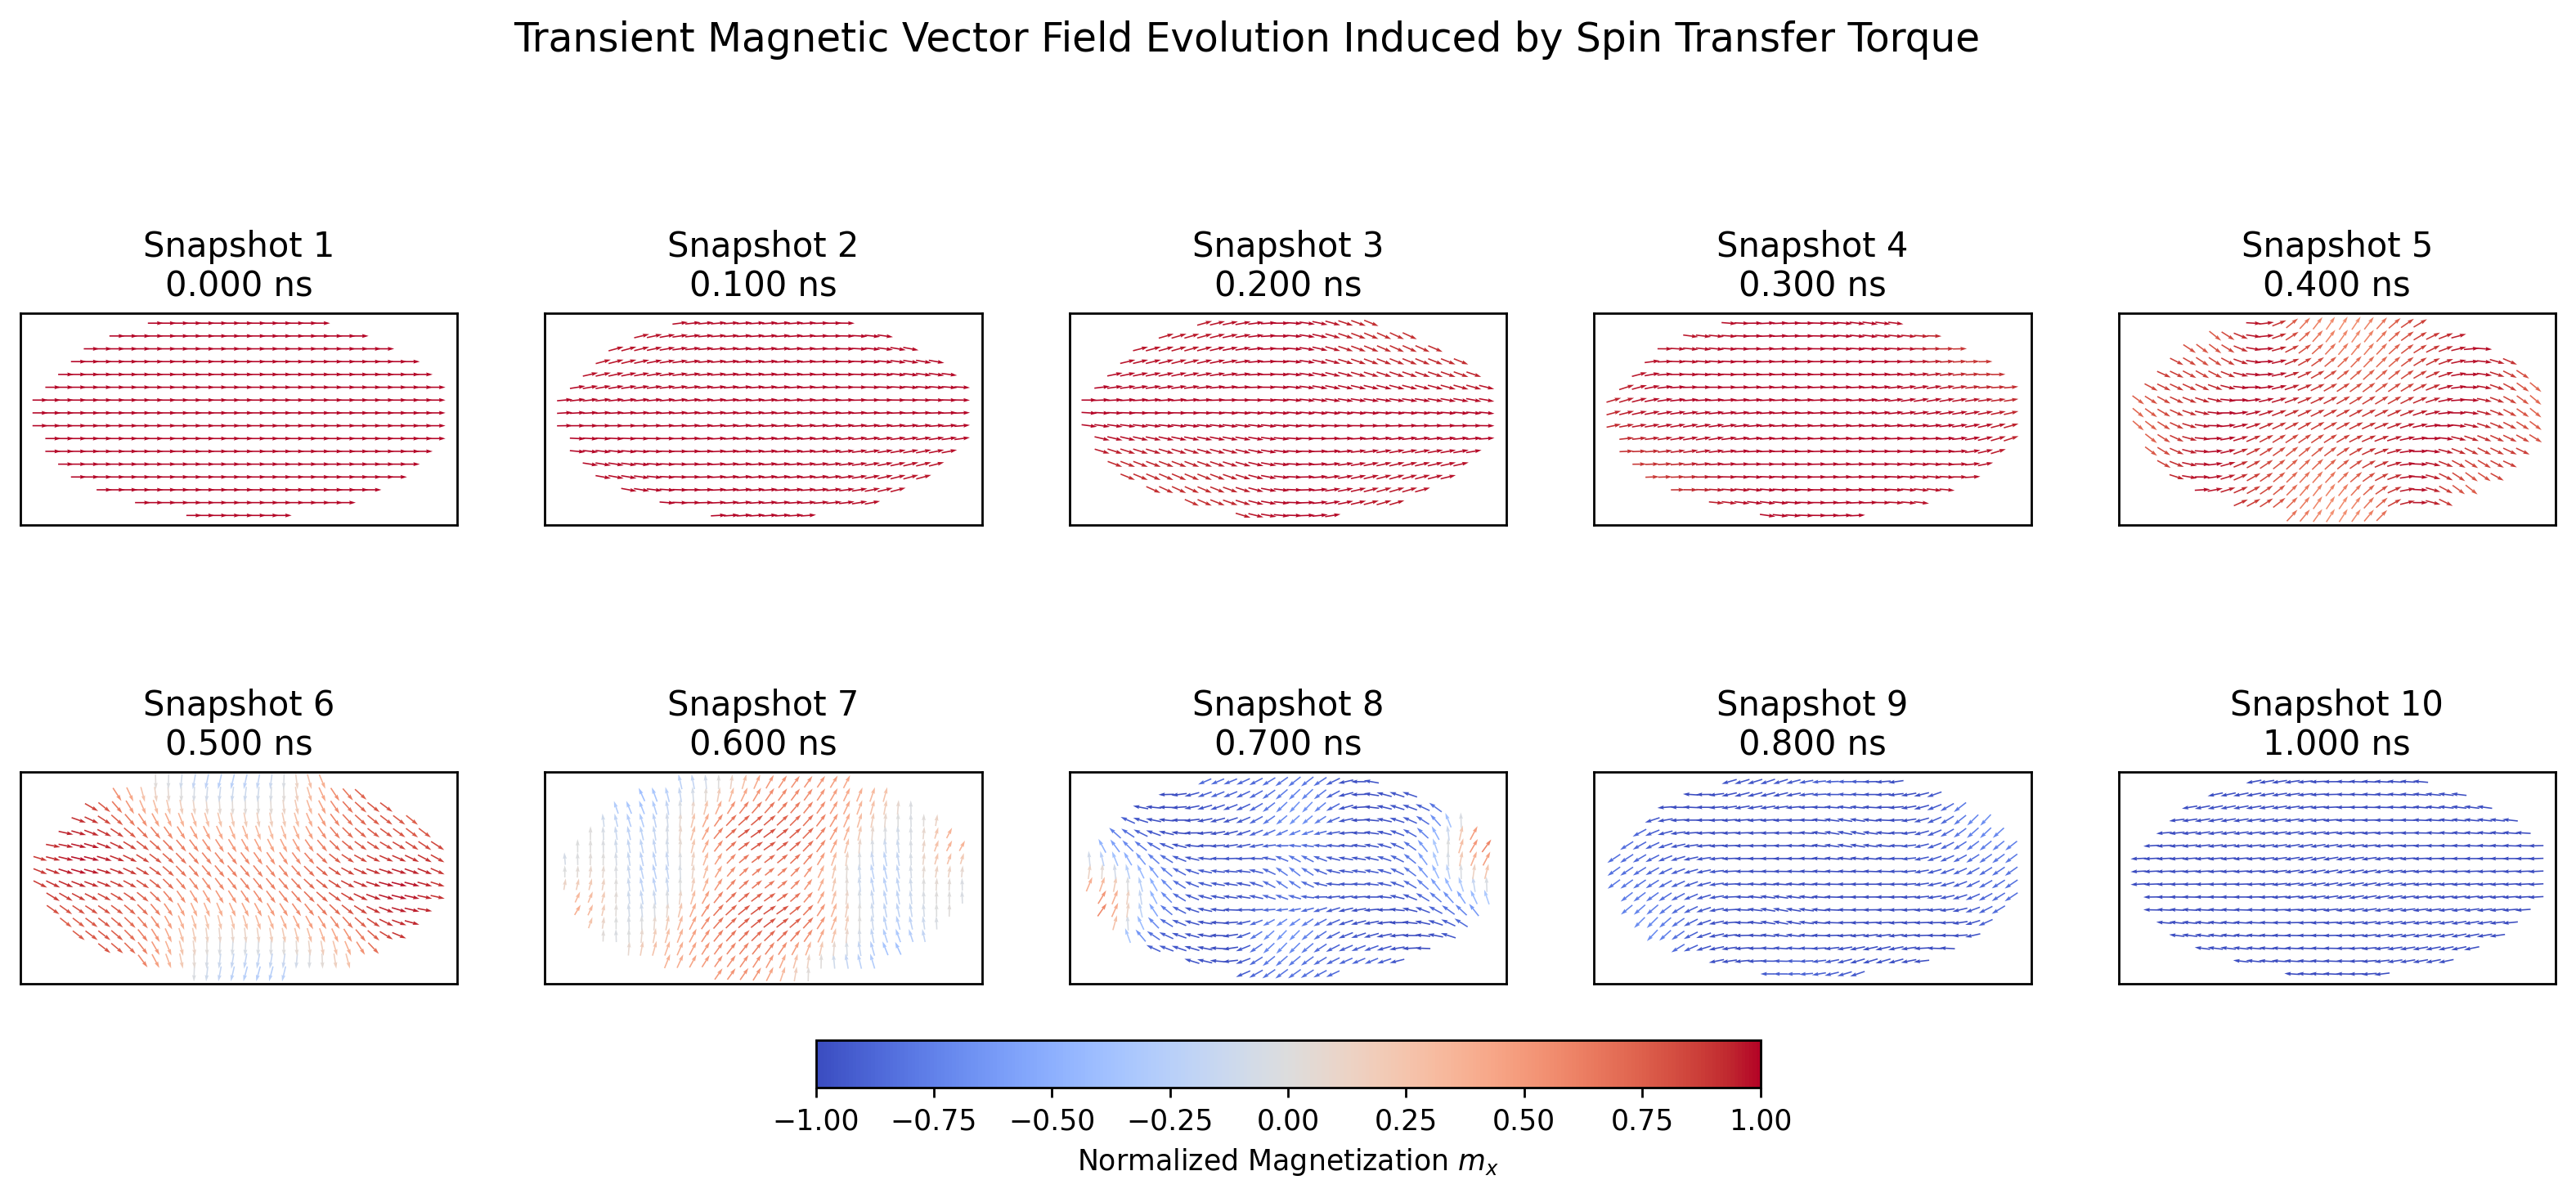


Cell 1 complete.
Prepared 10 spatial snapshots for the K3D visualization in Cell 2.


In [1]:
# ---------------------------------------------------
# Cell 1 - MuMax3 simulation + 1D and 2D results
# ---------------------------------------------------

# Install the complete two-cell environment once.
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!uv pip install -q -U "numpy>=2.3.5,<2.4" "scipy>=1.16,<1.17" pandas mpi4py k3d cupy-cuda12x trimesh matplotlib rtree embreex ipywidgets

from google.colab import output

output.enable_custom_widget_manager()


"""Run a MuMax3 spin-transfer-torque simulation and show 1D/2D results.

This first Colab cell prepares MuMax3, executes the Permalloy free-layer
simulation, plots the spatially averaged magnetization dynamics, converts
the saved OVF fields to NumPy arrays, and renders ten planar vector-field
snapshots. It intentionally leaves K3D rendering for Cell 2.
"""

# ---------------------------------------------------
# Standard Library Imports
# ---------------------------------------------------

import glob
import os
import re
import shutil
import subprocess
from pathlib import Path

# ---------------------------------------------------
# Scientific Imports
# ---------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import Normalize


# ---------------------------------------------------
# Control Knobs - MuMax3 Environment
# ---------------------------------------------------

MUMAX_URL = (
    "https://mumax.ugent.be/"
    "mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz"
)
ARCHIVE_NAME = "mumax3.12_linux_cuda12.9.tar.gz"
EXTRACTED_DIR = "mumax3.12_linux_cuda12.9"
TARGET_DIR = "mumax3.12"

SIMULATION_FILENAME = "stt_bit_cell.mx3"
RESULTS_DIRECTORY = "stt_bit_cell.out"
TABULAR_DATA_FILE = "table.txt"
CLEAN_PREVIOUS_RESULTS = True


# ---------------------------------------------------
# Control Knobs - Device Geometry
# ---------------------------------------------------

SIZE_X_NM = 160.0
SIZE_Y_NM = 80.0
SIZE_Z_NM = 5.0

GRID_NX = 64
GRID_NY = 32
GRID_NZ = 1


# ---------------------------------------------------
# Control Knobs - Permalloy Free Layer
# ---------------------------------------------------

MSAT_A_PER_M = 800.0e3
EXCHANGE_STIFFNESS_J_PER_M = 13.0e-12
GILBERT_DAMPING = 0.01

INITIAL_MX = 1.0
INITIAL_MY = 0.0
INITIAL_MZ = 0.0


# ---------------------------------------------------
# Control Knobs - Spin Transfer Torque
# ---------------------------------------------------

SLONCZEWSKI_LAMBDA = 1.0
POLARIZATION = 0.5669
EPSILON_PRIME = 0.0

FIXED_LAYER_ANGLE_DEG = 20.0
TOTAL_CURRENT_A = -0.008


# ---------------------------------------------------
# Control Knobs - Numerical Evolution
# ---------------------------------------------------

MAGNETIZATION_AUTOSAVE_S = 100.0e-12
TABLE_AUTOSAVE_S = 10.0e-12
TOTAL_SIMULATION_TIME_S = 1.0e-9


# ---------------------------------------------------
# Control Knobs - Matplotlib
# ---------------------------------------------------

FIGURE_RESOLUTION_DPI = 250
FONT_FAMILY_PREFERENCE = ["Tahoma", "DejaVu Sans"]
FONT_WEIGHT_PREFERENCE = "normal"

SNAPSHOT_ROWS = 2
SNAPSHOT_COLUMNS = 5
MAX_SNAPSHOTS = 10

QUIVER_SUBSAMPLING_STEP = 2
QUIVER_ARROW_SCALE = 28.0
MAGNETIZATION_MINIMUM_MAGNITUDE = 1.0e-6

MAGNETIZATION_COLOR_DIRECTION = "M_X"
# Accepted: "M_X", "M_Y", "M_Z", "MAGNITUDE"

COLOR_MIN = -1.0
COLOR_MAX = 1.0


# ---------------------------------------------------
# Matplotlib Configuration
# ---------------------------------------------------

plt.rcParams["figure.dpi"] = FIGURE_RESOLUTION_DPI
plt.rcParams["font.sans-serif"] = FONT_FAMILY_PREFERENCE
plt.rcParams["font.weight"] = FONT_WEIGHT_PREFERENCE


# ---------------------------------------------------
# Utility Functions Shared with Cell 2
# ---------------------------------------------------

def select_evenly_spaced_files(file_paths, maximum_count):
    """Select approximately uniform snapshots from an ordered file sequence."""
    file_paths = list(file_paths)

    if len(file_paths) <= maximum_count:
        return file_paths

    indices = np.linspace(
        0,
        len(file_paths) - 1,
        maximum_count,
        dtype=int,
    )
    return [file_paths[index] for index in indices]


def read_ovf_time_seconds(ovf_path):
    """Extract physical simulation time from a MuMax3 OVF header."""
    patterns = (
        re.compile(
            r"Total simulation time:\s*"
            r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
        ),
        re.compile(
            r"Time \(s\):\s*"
            r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
        ),
    )

    with open(ovf_path, "rb") as file:
        for _ in range(300):
            raw_line = file.readline()

            if raw_line == b"":
                break

            line = raw_line.decode(
                "utf-8",
                errors="ignore",
            ).strip()

            for pattern in patterns:
                match = pattern.search(line)

                if match:
                    return float(match.group(1))

            if "Begin: Data" in line:
                break

    return None


def ensure_vector_array_shape(vector_data):
    """Return MuMax3 vector data with shape (3, Nz, Ny, Nx)."""
    vector_data = np.asarray(vector_data)

    if vector_data.ndim == 4 and vector_data.shape[0] == 3:
        return vector_data

    if vector_data.ndim == 3 and vector_data.shape[0] == 3:
        return vector_data[:, np.newaxis, :, :]

    raise ValueError(
        "Unexpected MuMax3 NumPy field shape: "
        f"{vector_data.shape}. Expected (3, Nz, Ny, Nx)."
    )


def get_scalar_field(vector_data, component_name):
    """Return the scalar field used for color mapping."""
    mx_grid = vector_data[0]
    my_grid = vector_data[1]
    mz_grid = vector_data[2]

    if component_name == "M_X":
        return mx_grid
    if component_name == "M_Y":
        return my_grid
    if component_name == "M_Z":
        return mz_grid
    if component_name == "MAGNITUDE":
        return np.sqrt(
            mx_grid**2
            + my_grid**2
            + mz_grid**2
        )

    raise ValueError(
        "MAGNETIZATION_COLOR_DIRECTION must be "
        "'M_X', 'M_Y', 'M_Z', or 'MAGNITUDE'."
    )


def get_colorbar_label(component_name):
    """Return the mathematical label associated with the color quantity."""
    labels = {
        "M_X": r"Normalized Magnetization $m_x$",
        "M_Y": r"Normalized Magnetization $m_y$",
        "M_Z": r"Normalized Magnetization $m_z$",
        "MAGNITUDE": r"Magnetization Magnitude $|\mathbf{m}|$",
    }
    return labels[component_name]


def get_color_range(component_name):
    """Return the plotting range for the chosen scalar quantity."""
    if component_name == "MAGNITUDE":
        return 0.0, 1.0

    return COLOR_MIN, COLOR_MAX


# ---------------------------------------------------
# GPU Verification
# ---------------------------------------------------

subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,driver_version,compute_cap",
        "--format=csv",
    ],
    check=True,
)


# ---------------------------------------------------
# MuMax3 Environment Preparation
# ---------------------------------------------------

target_path = Path(TARGET_DIR)

if not target_path.exists():
    archive_path = Path(ARCHIVE_NAME)
    extracted_path = Path(EXTRACTED_DIR)

    if archive_path.exists():
        archive_path.unlink()

    if extracted_path.exists():
        shutil.rmtree(extracted_path)

    subprocess.run(
        [
            "wget",
            "-q",
            "-O",
            ARCHIVE_NAME,
            MUMAX_URL,
        ],
        check=True,
    )

    subprocess.run(
        [
            "tar",
            "-xf",
            ARCHIVE_NAME,
        ],
        check=True,
    )

    Path(ARCHIVE_NAME).unlink()
    extracted_path.rename(target_path)

mumax_directory = str(target_path.resolve())
os.environ["PATH"] = (
    f"{mumax_directory}:"
    f"{os.environ['PATH']}"
)


# ---------------------------------------------------
# Clear Previous Simulation Output
# ---------------------------------------------------

if CLEAN_PREVIOUS_RESULTS and Path(RESULTS_DIRECTORY).exists():
    shutil.rmtree(RESULTS_DIRECTORY)


# ---------------------------------------------------
# MuMax3 Simulation Configuration
# ---------------------------------------------------

mx3_configuration = f"""
// ---------------------------------------------------
// Geometry
// ---------------------------------------------------
sizeX := {SIZE_X_NM}e-9
sizeY := {SIZE_Y_NM}e-9
sizeZ := {SIZE_Z_NM}e-9
Nx := {GRID_NX}
Ny := {GRID_NY}
Nz := {GRID_NZ}
SetGridSize(Nx, Ny, Nz)
SetCellSize(sizeX/Nx, sizeY/Ny, sizeZ/Nz)
SetGeom(ellipse(sizeX, sizeY))

// ---------------------------------------------------
// Permalloy Free Layer
// ---------------------------------------------------
Msat = {MSAT_A_PER_M}
Aex = {EXCHANGE_STIFFNESS_J_PER_M}
alpha = {GILBERT_DAMPING}
m = Uniform({INITIAL_MX}, {INITIAL_MY}, {INITIAL_MZ})

// ---------------------------------------------------
// Slonczewski Spin Transfer Torque
// ---------------------------------------------------
DisableZhangLiTorque = true
Lambda = {SLONCZEWSKI_LAMBDA}
Pol = {POLARIZATION}
EpsilonPrime = {EPSILON_PRIME}

angle := {FIXED_LAYER_ANGLE_DEG}
px := cos(angle*pi/180)
py := sin(angle*pi/180)
FixedLayer = Vector(px, py, 0)

// ---------------------------------------------------
// Current Density
// ---------------------------------------------------
Jtot := {TOTAL_CURRENT_A}
area := sizeX*sizeY*pi/4
jc := Jtot/area
J = Vector(0, 0, jc)

// ---------------------------------------------------
// Output Schedule
// ---------------------------------------------------
AutoSave(m, {MAGNETIZATION_AUTOSAVE_S})
TableAutoSave({TABLE_AUTOSAVE_S})
Run({TOTAL_SIMULATION_TIME_S})
"""

with open(
    SIMULATION_FILENAME,
    "w",
    encoding="utf-8",
) as file:
    file.write(mx3_configuration)


# ---------------------------------------------------
# MuMax3 Input Preflight
# ---------------------------------------------------

vet_result = subprocess.run(
    [
        "mumax3",
        "-http=",
        "-vet",
        SIMULATION_FILENAME,
    ],
    check=False,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

if vet_result.stdout:
    print(vet_result.stdout)

if vet_result.returncode != 0:
    raise RuntimeError(
        "MuMax3 rejected the generated input script during the -vet "
        f"preflight with exit code {vet_result.returncode}."
    )


# ---------------------------------------------------
# Numerical Execution
# ---------------------------------------------------

mumax_result = subprocess.run(
    [
        "mumax3",
        "-http=",
        SIMULATION_FILENAME,
    ],
    check=False,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

if mumax_result.stdout:
    print(mumax_result.stdout)

if mumax_result.returncode != 0:
    raise RuntimeError(
        "MuMax3 failed during numerical execution with exit code "
        f"{mumax_result.returncode}."
    )


# ---------------------------------------------------
# Tabular Data Ingestion
# ---------------------------------------------------

data_path = os.path.join(
    RESULTS_DIRECTORY,
    TABULAR_DATA_FILE,
)

simulation_data = pd.read_csv(
    data_path,
    sep="\t",
)

simulation_data.columns = [
    column.strip()
    for column in simulation_data.columns
]


def find_table_column(prefix):
    """Find a MuMax3 table column from its leading text."""
    matching_columns = [
        column
        for column in simulation_data.columns
        if column.startswith(prefix)
    ]

    if not matching_columns:
        raise KeyError(
            f"Could not locate table column beginning with '{prefix}'."
        )

    return matching_columns[0]


time_column = find_table_column("# t")
mx_column = find_table_column("mx")
my_column = find_table_column("my")
mz_column = find_table_column("mz")

time_array_ns = (
    simulation_data[time_column].to_numpy()
    * 1.0e9
)
mx_component = simulation_data[mx_column].to_numpy()
my_component = simulation_data[my_column].to_numpy()
mz_component = simulation_data[mz_column].to_numpy()


# ---------------------------------------------------
# 1D Magnetization Time Series
# ---------------------------------------------------

fig_timeseries, ax_timeseries = plt.subplots(
    figsize=(8, 4)
)

ax_timeseries.plot(
    time_array_ns,
    mx_component,
    label=r"$m_x$",
    color="#0000FF",
    linestyle="solid",
    linewidth=1.5,
)
ax_timeseries.plot(
    time_array_ns,
    my_component,
    label=r"$m_y$",
    color="#0000FF",
    linestyle="dashed",
    linewidth=1.5,
)
ax_timeseries.plot(
    time_array_ns,
    mz_component,
    label=r"$m_z$",
    color="#0000FF",
    linestyle="dotted",
    linewidth=1.5,
)

ax_timeseries.set_xlabel("Time (ns)")
ax_timeseries.set_ylabel("Normalized Magnetization")
ax_timeseries.set_title(
    "Magnetization Dynamics Induced by Spin Transfer Torque"
)
ax_timeseries.legend(
    loc="upper right",
    frameon=True,
)
ax_timeseries.grid(
    True,
    linestyle=":",
    alpha=0.6,
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Locate and Convert MuMax3 Spatial Snapshots
# ---------------------------------------------------

all_ovf_files = sorted(
    glob.glob(
        os.path.join(
            RESULTS_DIRECTORY,
            "*.ovf",
        )
    )
)

if not all_ovf_files:
    raise FileNotFoundError(
        "MuMax3 produced no OVF magnetization files."
    )

selected_ovf_files = select_evenly_spaced_files(
    all_ovf_files,
    MAX_SNAPSHOTS,
)

snapshot_records = []

for ovf_file in selected_ovf_files:
    snapshot_time_s = read_ovf_time_seconds(
        ovf_file
    )

    subprocess.run(
        [
            "mumax3-convert",
            "-numpy",
            ovf_file,
        ],
        check=True,
    )

    npy_file = str(
        Path(ovf_file).with_suffix(".npy")
    )

    if not Path(npy_file).exists():
        raise FileNotFoundError(
            f"Expected converted field file {npy_file}."
        )

    snapshot_records.append(
        {
            "ovf": ovf_file,
            "npy": npy_file,
            "time_s": snapshot_time_s,
        }
    )


# ---------------------------------------------------
# 2D Magnetic Vector Field Snapshots
# ---------------------------------------------------

fig_vectors, axes = plt.subplots(
    SNAPSHOT_ROWS,
    SNAPSHOT_COLUMNS,
    figsize=(16, 6),
)

axes_flat = np.asarray(
    axes
).reshape(-1)

color_min, color_max = get_color_range(
    MAGNETIZATION_COLOR_DIRECTION
)

quiver_normalization = Normalize(
    vmin=color_min,
    vmax=color_max,
)

quiver_plot = None

for index, record in enumerate(snapshot_records):
    vector_data = ensure_vector_array_shape(
        np.load(record["npy"])
    )

    _, nz_points, ny_points, nx_points = (
        vector_data.shape
    )

    central_z_index = nz_points // 2

    mx_grid = vector_data[
        0,
        central_z_index,
        :,
        :,
    ]
    my_grid = vector_data[
        1,
        central_z_index,
        :,
        :,
    ]
    mz_grid = vector_data[
        2,
        central_z_index,
        :,
        :,
    ]

    color_grid = get_scalar_field(
        vector_data,
        MAGNETIZATION_COLOR_DIRECTION,
    )[
        central_z_index,
        :,
        :,
    ]

    x_coordinates, y_coordinates = np.meshgrid(
        np.arange(nx_points),
        np.arange(ny_points),
    )

    slice_y = slice(
        0,
        ny_points,
        QUIVER_SUBSAMPLING_STEP,
    )
    slice_x = slice(
        0,
        nx_points,
        QUIVER_SUBSAMPLING_STEP,
    )

    full_magnitude = np.sqrt(
        mx_grid**2
        + my_grid**2
        + mz_grid**2
    )

    active_mask = (
        full_magnitude[
            slice_y,
            slice_x,
        ]
        > MAGNETIZATION_MINIMUM_MAGNITUDE
    )

    x_plot = x_coordinates[
        slice_y,
        slice_x,
    ][active_mask]
    y_plot = y_coordinates[
        slice_y,
        slice_x,
    ][active_mask]

    mx_plot = mx_grid[
        slice_y,
        slice_x,
    ][active_mask]
    my_plot = my_grid[
        slice_y,
        slice_x,
    ][active_mask]
    color_plot = color_grid[
        slice_y,
        slice_x,
    ][active_mask]

    axis = axes_flat[index]

    quiver_plot = axis.quiver(
        x_plot,
        y_plot,
        mx_plot,
        my_plot,
        color_plot,
        cmap="coolwarm",
        norm=quiver_normalization,
        pivot="mid",
        scale=QUIVER_ARROW_SCALE,
    )

    snapshot_time_s = record["time_s"]

    if snapshot_time_s is None:
        title = f"Snapshot {index + 1}"
    else:
        title = (
            f"Snapshot {index + 1}\n"
            f"{snapshot_time_s * 1.0e9:.3f} ns"
        )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_aspect("equal")

for index in range(
    len(snapshot_records),
    len(axes_flat),
):
    axes_flat[index].axis("off")

if quiver_plot is None:
    raise RuntimeError(
        "No vector field was available for plotting."
    )

colorbar = fig_vectors.colorbar(
    quiver_plot,
    ax=axes_flat.tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
)
colorbar.set_label(
    get_colorbar_label(
        MAGNETIZATION_COLOR_DIRECTION
    )
)

fig_vectors.suptitle(
    "Transient Magnetic Vector Field Evolution "
    "Induced by Spin Transfer Torque",
    fontsize=14,
)

plt.show()

print()
print("Cell 1 complete.")
print(
    f"Prepared {len(snapshot_records)} spatial snapshots "
    "for the K3D visualization in Cell 2."
)

In [6]:
# ---------------------------------------------------
# Cell 2 - K3D 3D vector fields
# ---------------------------------------------------

"""Render MuMax3 magnetization snapshots as cylinder-and-cone 3D arrows.

Run Cell 1 first. This cell reuses the converted MuMax3 NumPy snapshots,
renders each magnetic vector as a cylindrical K3D line shaft plus a
triangular cone mesh tip, serves the standalone K3D scenes through the
Colab proxy, and provides both an inline gallery and an explicit new-tab link.
"""

# ---------------------------------------------------
# Imports
# ---------------------------------------------------

from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
import socket
import threading
from urllib.parse import quote

import k3d
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import HTML, IFrame, display


# ---------------------------------------------------
# Cell 1 State Check
# ---------------------------------------------------

_REQUIRED_CELL_1_GLOBALS = (
    "snapshot_records",
    "SIZE_X_NM",
    "SIZE_Y_NM",
    "SIZE_Z_NM",
    "MAGNETIZATION_COLOR_DIRECTION",
    "ensure_vector_array_shape",
    "get_scalar_field",
    "get_color_range",
)

_missing_cell_1_globals = [
    name
    for name in _REQUIRED_CELL_1_GLOBALS
    if name not in globals()
]

if _missing_cell_1_globals:
    raise RuntimeError(
        "Run Cell 1 before Cell 2. Missing Cell 1 state: "
        + ", ".join(_missing_cell_1_globals)
    )


# ---------------------------------------------------
# Control Knobs - K3D Sampling
# ---------------------------------------------------

K3D_INITIAL_SNAPSHOT = 0

# This sampling affects only the 3D display density.
K3D_SUBSAMPLING_X = 4
K3D_SUBSAMPLING_Y = 4
K3D_SUBSAMPLING_Z = 1

K3D_VECTOR_LENGTH_NM = 6.0
K3D_MINIMUM_MAGNITUDE = 1.0e-6
K3D_NORMALIZE_GLYPHS = True


# ---------------------------------------------------
# Control Knobs - Cylinder Shaft + Cone Tip
# ---------------------------------------------------

# k3d.lines with shader="mesh" produces tube-like cylindrical shafts.
K3D_SHAFT_WIDTH_NM = 0.42
K3D_SHAFT_RADIAL_SEGMENTS = 8

# Every cone is explicit triangular mesh geometry.
K3D_CONE_LENGTH_NM = 1.9
K3D_CONE_RADIUS_NM = 1.15
K3D_CONE_RADIAL_SEGMENTS = 12
K3D_CONE_SHININESS = 35.0

# Raise a one-layer magnetic field above the film for visibility.
K3D_LIFT_SINGLE_LAYER_GLYPHS = True
K3D_SURFACE_GAP_NM = 1.5


# ---------------------------------------------------
# Control Knobs - K3D Scene
# ---------------------------------------------------

K3D_PLOT_HEIGHT = 650
K3D_GALLERY_HEIGHT = 760

K3D_BACKGROUND_COLOR = 0x1E1E1E
K3D_GRID_COLOR = 0x5B6470
K3D_LABEL_COLOR = 0xF0F0F0
K3D_GRID_VISIBLE = True

K3D_SHOW_DEVICE_OUTLINE = True
K3D_DEVICE_OUTLINE_COLOR = 0xA0A7B0
K3D_DEVICE_OUTLINE_WIDTH_NM = 0.18
K3D_DEVICE_OUTLINE_SEGMENTS = 160

K3D_COLOR_MIN = -1.0
K3D_COLOR_MAX = 1.0


# ---------------------------------------------------
# Control Knobs - Inline / New Tab Viewer
# ---------------------------------------------------

K3D_SHOW_INLINE_GALLERY = True
K3D_SHOW_NEW_TAB_LINK = True

# Leave this False for normal use. A user-clicked hyperlink is more reliable
# in Colab than a programmatic popup.
K3D_AUTO_OPEN_RESULTS_IN_NEW_TAB = False

K3D_OUTPUT_DIRECTORY = Path("mumax3_k3d_output")
K3D_GALLERY_FILENAME = "mumax3_vector_field_gallery.html"
K3D_SERVER_BIND = "127.0.0.1"

# Persistent Colab-local HTTP server state.
_K3D_HTTP_SERVER = None
_K3D_HTTP_THREAD = None
_K3D_HTTP_PORT = None
_K3D_PROXY_BASE_URL = None


# ---------------------------------------------------
# K3D Colab Configuration
# ---------------------------------------------------

def configure_k3d_snapshot_protocol():
    """Select K3D's Colab-compatible text serialization protocol."""
    switch_protocol = getattr(
        k3d,
        "switch_to_text_protocol",
        None,
    )

    if callable(switch_protocol):
        switch_protocol()


configure_k3d_snapshot_protocol()


# ---------------------------------------------------
# K3D Colormap
# ---------------------------------------------------

K3D_COOLWARM = [
    [
        float(position),
        float(red),
        float(green),
        float(blue),
    ]
    for position, (red, green, blue, _) in zip(
        np.linspace(0.0, 1.0, 256),
        plt.get_cmap("coolwarm")(
            np.linspace(0.0, 1.0, 256)
        ),
    )
]


# ---------------------------------------------------
# Geometry Utilities
# ---------------------------------------------------

def build_ellipse_outline_vertices(z_nm):
    """Return an indexed ellipse at the selected z coordinate."""
    angles = np.linspace(
        0.0,
        2.0 * np.pi,
        K3D_DEVICE_OUTLINE_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )

    vertices = np.column_stack(
        (
            0.5 * SIZE_X_NM * np.cos(angles),
            0.5 * SIZE_Y_NM * np.sin(angles),
            np.full(
                angles.shape,
                z_nm,
                dtype=np.float32,
            ),
        )
    ).astype(np.float32)

    vertex_ids = np.arange(
        vertices.shape[0],
        dtype=np.uint32,
    )

    indices = np.column_stack(
        (
            vertex_ids,
            np.roll(vertex_ids, -1),
        )
    )

    return (
        np.ascontiguousarray(
            vertices,
            dtype=np.float32,
        ),
        np.ascontiguousarray(
            indices,
            dtype=np.uint32,
        ),
    )


def build_cylinder_cone_arrow_geometry(
    origins,
    vectors,
    scalar_values,
):
    """Build cylindrical shaft segments and explicit cone-tip meshes.

    Args:
        origins: Arrow origins with shape (N, 3).
        vectors: Display vectors with shape (N, 3).
        scalar_values: Scalar color value for every arrow.

    Returns:
        Dictionary containing indexed shaft geometry and cone mesh geometry.
    """
    origins = np.ascontiguousarray(
        origins,
        dtype=np.float32,
    )
    vectors = np.ascontiguousarray(
        vectors,
        dtype=np.float32,
    )
    scalar_values = np.ascontiguousarray(
        scalar_values,
        dtype=np.float32,
    )

    if origins.shape != vectors.shape:
        raise ValueError(
            "origins and vectors must have identical shapes."
        )

    if (
        origins.ndim != 2
        or origins.shape[1] != 3
    ):
        raise ValueError(
            "origins and vectors must have shape (N, 3)."
        )

    if scalar_values.shape != (origins.shape[0],):
        raise ValueError(
            "scalar_values must have shape (N,)."
        )

    shaft_vertices = []
    shaft_attributes = []

    cone_vertex_blocks = []
    cone_index_blocks = []
    cone_attribute_blocks = []
    cone_vertex_offset = 0

    angles = np.linspace(
        0.0,
        2.0 * np.pi,
        K3D_CONE_RADIAL_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )
    cos_angles = np.cos(angles)
    sin_angles = np.sin(angles)

    for origin, vector, scalar in zip(
        origins,
        vectors,
        scalar_values,
    ):
        length = float(
            np.linalg.norm(vector)
        )

        if length <= K3D_MINIMUM_MAGNITUDE:
            continue

        direction = vector / length
        tip = origin + vector

        cone_length = min(
            K3D_CONE_LENGTH_NM,
            0.45 * length,
        )
        cone_radius = min(
            K3D_CONE_RADIUS_NM,
            0.30 * length,
        )

        cone_base_center = (
            tip
            - cone_length * direction
        )

        # Shaft stops at the cone base, producing the usual
        # cylinder + cone arrow construction.
        shaft_vertices.extend(
            (
                origin,
                cone_base_center,
            )
        )
        shaft_attributes.extend(
            (
                scalar,
                scalar,
            )
        )

        reference = np.asarray(
            [0.0, 0.0, 1.0],
            dtype=np.float32,
        )

        if (
            abs(
                float(
                    np.dot(
                        direction,
                        reference,
                    )
                )
            )
            > 0.90
        ):
            reference = np.asarray(
                [0.0, 1.0, 0.0],
                dtype=np.float32,
            )

        basis_u = np.cross(
            direction,
            reference,
        )

        basis_u_norm = float(
            np.linalg.norm(basis_u)
        )

        if basis_u_norm <= 1.0e-12:
            continue

        basis_u /= basis_u_norm

        basis_v = np.cross(
            direction,
            basis_u,
        )

        basis_v /= max(
            float(
                np.linalg.norm(
                    basis_v
                )
            ),
            1.0e-12,
        )

        ring_direction = (
            cos_angles[:, np.newaxis]
            * basis_u[np.newaxis, :]
            + sin_angles[:, np.newaxis]
            * basis_v[np.newaxis, :]
        )

        base_ring = (
            cone_base_center[np.newaxis, :]
            + cone_radius * ring_direction
        ).astype(np.float32)

        local_vertices = np.vstack(
            (
                base_ring,
                tip[np.newaxis, :],
                cone_base_center[np.newaxis, :],
            )
        ).astype(np.float32)

        tip_index = K3D_CONE_RADIAL_SEGMENTS
        base_center_index = tip_index + 1

        local_indices = []

        for index in range(
            K3D_CONE_RADIAL_SEGMENTS
        ):
            next_index = (
                index + 1
            ) % K3D_CONE_RADIAL_SEGMENTS

            # Cone lateral surface.
            local_indices.append(
                [
                    index,
                    next_index,
                    tip_index,
                ]
            )

            # Cone base cap.
            local_indices.append(
                [
                    base_center_index,
                    next_index,
                    index,
                ]
            )

        local_indices = np.asarray(
            local_indices,
            dtype=np.uint32,
        )
        local_indices += cone_vertex_offset

        cone_vertex_blocks.append(
            local_vertices
        )
        cone_index_blocks.append(
            local_indices
        )
        cone_attribute_blocks.append(
            np.full(
                local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )

        cone_vertex_offset += (
            local_vertices.shape[0]
        )

    if not shaft_vertices:
        raise RuntimeError(
            "No K3D shaft geometry was generated."
        )

    if not cone_vertex_blocks:
        raise RuntimeError(
            "No K3D cone geometry was generated."
        )

    shaft_vertices_array = np.ascontiguousarray(
        np.asarray(
            shaft_vertices,
            dtype=np.float32,
        ),
        dtype=np.float32,
    )

    shaft_attributes_array = np.ascontiguousarray(
        np.asarray(
            shaft_attributes,
            dtype=np.float32,
        ),
        dtype=np.float32,
    )

    shaft_indices = np.arange(
        shaft_vertices_array.shape[0],
        dtype=np.uint32,
    ).reshape(-1, 2)

    cone_vertices = np.ascontiguousarray(
        np.vstack(
            cone_vertex_blocks
        ),
        dtype=np.float32,
    )

    cone_indices = np.ascontiguousarray(
        np.vstack(
            cone_index_blocks
        ),
        dtype=np.uint32,
    )

    cone_attributes = np.ascontiguousarray(
        np.concatenate(
            cone_attribute_blocks
        ),
        dtype=np.float32,
    )

    return {
        "shaft_vertices": shaft_vertices_array,
        "shaft_indices": np.ascontiguousarray(
            shaft_indices,
            dtype=np.uint32,
        ),
        "shaft_attributes": shaft_attributes_array,
        "cone_vertices": cone_vertices,
        "cone_indices": cone_indices,
        "cone_attributes": cone_attributes,
    }


def prepare_k3d_frame(npy_path):
    """Convert one MuMax3 snapshot into cylinder-and-cone arrow geometry."""
    vector_data = ensure_vector_array_shape(
        np.load(npy_path)
    )

    _, nz_points, ny_points, nx_points = (
        vector_data.shape
    )

    mx_grid = vector_data[0]
    my_grid = vector_data[1]
    mz_grid = vector_data[2]

    dx_nm = SIZE_X_NM / nx_points
    dy_nm = SIZE_Y_NM / ny_points
    dz_nm = SIZE_Z_NM / nz_points

    x_coordinates = (
        (
            np.arange(
                nx_points,
                dtype=np.float32,
            )
            + 0.5
        )
        * dx_nm
        - SIZE_X_NM / 2.0
    )

    y_coordinates = (
        (
            np.arange(
                ny_points,
                dtype=np.float32,
            )
            + 0.5
        )
        * dy_nm
        - SIZE_Y_NM / 2.0
    )

    z_coordinates = (
        (
            np.arange(
                nz_points,
                dtype=np.float32,
            )
            + 0.5
        )
        * dz_nm
        - SIZE_Z_NM / 2.0
    )

    z_grid, y_grid, x_grid = np.meshgrid(
        z_coordinates,
        y_coordinates,
        x_coordinates,
        indexing="ij",
    )

    z_slice = slice(
        0,
        nz_points,
        K3D_SUBSAMPLING_Z,
    )
    y_slice = slice(
        0,
        ny_points,
        K3D_SUBSAMPLING_Y,
    )
    x_slice = slice(
        0,
        nx_points,
        K3D_SUBSAMPLING_X,
    )

    mx_sub = mx_grid[
        z_slice,
        y_slice,
        x_slice,
    ]
    my_sub = my_grid[
        z_slice,
        y_slice,
        x_slice,
    ]
    mz_sub = mz_grid[
        z_slice,
        y_slice,
        x_slice,
    ]

    x_sub = x_grid[
        z_slice,
        y_slice,
        x_slice,
    ]
    y_sub = y_grid[
        z_slice,
        y_slice,
        x_slice,
    ]
    z_sub = z_grid[
        z_slice,
        y_slice,
        x_slice,
    ]

    vector_magnitude = np.sqrt(
        mx_sub**2
        + my_sub**2
        + mz_sub**2
    )

    active_mask = (
        vector_magnitude
        > K3D_MINIMUM_MAGNITUDE
    )

    origins = np.column_stack(
        (
            x_sub[active_mask],
            y_sub[active_mask],
            z_sub[active_mask],
        )
    ).astype(np.float32)

    raw_vectors = np.column_stack(
        (
            mx_sub[active_mask],
            my_sub[active_mask],
            mz_sub[active_mask],
        )
    ).astype(np.float32)

    if origins.shape[0] == 0:
        raise RuntimeError(
            f"No active magnetic cells were found in {npy_path}."
        )

    if not np.all(
        np.isfinite(origins)
    ):
        raise RuntimeError(
            f"Non-finite K3D origins were generated from {npy_path}."
        )

    if not np.all(
        np.isfinite(raw_vectors)
    ):
        raise RuntimeError(
            f"Non-finite magnetization vectors were found in {npy_path}."
        )

    if (
        nz_points == 1
        and K3D_LIFT_SINGLE_LAYER_GLYPHS
    ):
        origins[:, 2] = (
            SIZE_Z_NM / 2.0
            + K3D_SURFACE_GAP_NM
        )

    magnitudes = np.linalg.norm(
        raw_vectors,
        axis=1,
    )

    if K3D_NORMALIZE_GLYPHS:
        safe_magnitudes = np.maximum(
            magnitudes,
            K3D_MINIMUM_MAGNITUDE,
        )

        glyph_vectors = (
            raw_vectors
            / safe_magnitudes[:, np.newaxis]
        )
        glyph_vectors *= (
            K3D_VECTOR_LENGTH_NM
        )
    else:
        glyph_vectors = (
            raw_vectors
            * K3D_VECTOR_LENGTH_NM
        )

    scalar_grid = get_scalar_field(
        vector_data,
        MAGNETIZATION_COLOR_DIRECTION,
    )

    scalar_sub = scalar_grid[
        z_slice,
        y_slice,
        x_slice,
    ]

    scalar_values = scalar_sub[
        active_mask
    ].astype(np.float32)

    arrow_geometry = (
        build_cylinder_cone_arrow_geometry(
            origins,
            glyph_vectors,
            scalar_values,
        )
    )

    return {
        "origins": np.ascontiguousarray(
            origins,
            dtype=np.float32,
        ),
        "vectors": np.ascontiguousarray(
            glyph_vectors,
            dtype=np.float32,
        ),
        "scalars": np.ascontiguousarray(
            scalar_values,
            dtype=np.float32,
        ),
        **arrow_geometry,
    }


# ---------------------------------------------------
# Prepare All K3D Frames
# ---------------------------------------------------

k3d_frames = [
    prepare_k3d_frame(
        record["npy"]
    )
    for record in snapshot_records
]

if not k3d_frames:
    raise RuntimeError(
        "No K3D frames were generated."
    )

initial_index = int(
    np.clip(
        K3D_INITIAL_SNAPSHOT,
        0,
        len(k3d_frames) - 1,
    )
)


# ---------------------------------------------------
# K3D Scene Builders
# ---------------------------------------------------

def create_k3d_base_plot(
    height=K3D_PLOT_HEIGHT,
):
    """Create a fixed physical K3D scene in nanometer coordinates."""
    configure_k3d_snapshot_protocol()

    glyph_plane_z = (
        SIZE_Z_NM / 2.0
        + K3D_SURFACE_GAP_NM
    )

    z_upper = (
        glyph_plane_z
        + K3D_VECTOR_LENGTH_NM
        + K3D_CONE_RADIUS_NM
        + 2.0
    )

    z_lower = -max(
        SIZE_Z_NM,
        0.45 * K3D_VECTOR_LENGTH_NM,
    )

    plot = k3d.plot(
        height=height,
        background_color=K3D_BACKGROUND_COLOR,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        camera_auto_fit=False,
        grid_auto_fit=False,
        grid_visible=K3D_GRID_VISIBLE,
        grid=(
            -SIZE_X_NM / 2.0,
            -SIZE_Y_NM / 2.0,
            z_lower,
            SIZE_X_NM / 2.0,
            SIZE_Y_NM / 2.0,
            z_upper,
        ),
        axes=[
            "x (nm)",
            "y (nm)",
            "z (nm)",
        ],
        camera_mode="trackball",
        screenshot_scale=2.0,
        snapshot_type="full",
    )

    target_z = glyph_plane_z

    plot.camera = [
        0.68 * SIZE_X_NM,
        -1.22 * SIZE_Y_NM,
        target_z + 0.68 * SIZE_X_NM,
        0.0,
        0.0,
        target_z,
        0.0,
        0.0,
        1.0,
    ]

    return plot


def add_k3d_device_outline(plot):
    """Add the top ellipse of the Permalloy free layer."""
    if not K3D_SHOW_DEVICE_OUTLINE:
        return

    vertices, indices = (
        build_ellipse_outline_vertices(
            SIZE_Z_NM / 2.0
        )
    )

    plot += k3d.lines(
        vertices=vertices,
        indices=indices,
        indices_type="segment",
        color=K3D_DEVICE_OUTLINE_COLOR,
        width=K3D_DEVICE_OUTLINE_WIDTH_NM,
        shader="mesh",
        radial_segments=5,
        opacity=0.75,
        name="Permalloy top-surface outline",
    )


def add_k3d_cylinder_cone_arrows(
    plot,
    frame,
    name,
):
    """Add cylindrical shafts and cone tips for one magnetic field frame."""
    color_range = list(
        get_color_range(
            MAGNETIZATION_COLOR_DIRECTION
        )
    )

    shaft_drawable = k3d.lines(
        vertices=np.ascontiguousarray(
            frame["shaft_vertices"],
            dtype=np.float32,
        ),
        indices=np.ascontiguousarray(
            frame["shaft_indices"],
            dtype=np.uint32,
        ),
        indices_type="segment",
        attribute=np.ascontiguousarray(
            frame["shaft_attributes"],
            dtype=np.float32,
        ),
        color_map=K3D_COOLWARM,
        color_range=color_range,
        shader="mesh",
        width=K3D_SHAFT_WIDTH_NM,
        radial_segments=(
            K3D_SHAFT_RADIAL_SEGMENTS
        ),
        opacity=1.0,
        name=f"{name} - cylindrical shafts",
    )

    cone_drawable = k3d.mesh(
        vertices=np.ascontiguousarray(
            frame["cone_vertices"],
            dtype=np.float32,
        ),
        indices=np.ascontiguousarray(
            frame["cone_indices"],
            dtype=np.uint32,
        ),
        attribute=np.ascontiguousarray(
            frame["cone_attributes"],
            dtype=np.float32,
        ),
        color_map=K3D_COOLWARM,
        color_range=color_range,
        wireframe=False,
        flat_shading=True,
        shininess=K3D_CONE_SHININESS,
        opacity=1.0,
        side="double",
        name=f"{name} - cone tips",
    )

    plot += shaft_drawable
    plot += cone_drawable

    # Keep one colorbar tied to the shaft scalar field.
    if hasattr(
        shaft_drawable,
        "id",
    ):
        plot.colorbar_object_id = (
            shaft_drawable.id
        )


def build_k3d_static_scene(
    frame,
    frame_index,
):
    """Build one standalone 3D magnetic-vector scene."""
    plot = create_k3d_base_plot()

    add_k3d_device_outline(
        plot
    )

    add_k3d_cylinder_cone_arrows(
        plot,
        frame,
        name=(
            "Magnetization arrows, "
            f"snapshot {frame_index + 1}"
        ),
    )

    return plot


# ---------------------------------------------------
# Standalone K3D Files and Colab Proxy Server
# ---------------------------------------------------

class QuietK3DRequestHandler(
    SimpleHTTPRequestHandler
):
    """Serve K3D files and make the server root open the gallery."""

    def do_GET(self):
        """Serve the gallery at ``/`` as a Colab new-tab fallback."""
        request_path = self.path.split("?", 1)[0]

        # Colab/browser navigation can occasionally drop the gallery filename
        # and open only the proxied server root. Rewriting that request here
        # makes the root URL display the gallery instead of returning 404.
        if request_path in ("", "/"):
            self.path = f"/{K3D_GALLERY_FILENAME}"

        super().do_GET()

    def log_message(
        self,
        format,
        *args,
    ):
        """Suppress HTTP access logging."""


def find_available_local_port():
    """Return an available local TCP port."""
    with socket.socket(
        socket.AF_INET,
        socket.SOCK_STREAM,
    ) as probe:
        probe.bind(
            (
                K3D_SERVER_BIND,
                0,
            )
        )

        return int(
            probe.getsockname()[1]
        )


def start_k3d_result_server():
    """Start the persistent Colab-local K3D result server."""
    global _K3D_HTTP_PORT
    global _K3D_HTTP_SERVER
    global _K3D_HTTP_THREAD
    global _K3D_PROXY_BASE_URL

    if (
        _K3D_HTTP_SERVER is not None
        and _K3D_HTTP_THREAD is not None
        and _K3D_HTTP_THREAD.is_alive()
        and _K3D_HTTP_PORT is not None
        and _K3D_PROXY_BASE_URL is not None
    ):
        return (
            _K3D_HTTP_PORT,
            _K3D_PROXY_BASE_URL,
        )

    from google.colab import output

    K3D_OUTPUT_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    port = find_available_local_port()

    handler = partial(
        QuietK3DRequestHandler,
        directory=str(
            K3D_OUTPUT_DIRECTORY.resolve()
        ),
    )

    server = ThreadingHTTPServer(
        (
            K3D_SERVER_BIND,
            port,
        ),
        handler,
    )
    server.daemon_threads = True

    server_thread = threading.Thread(
        target=server.serve_forever,
        name="mumax3-k3d-http-server",
        daemon=True,
    )
    server_thread.start()

    proxy_base_url = str(
        output.eval_js(
            "google.colab.kernel."
            f"proxyPort({port})"
        )
    ).rstrip("/")

    _K3D_HTTP_PORT = port
    _K3D_HTTP_SERVER = server
    _K3D_HTTP_THREAD = server_thread
    _K3D_PROXY_BASE_URL = proxy_base_url

    print(
        "K3D result server | "
        f"port={port} | "
        f"proxy={proxy_base_url}"
    )

    return (
        port,
        proxy_base_url,
    )


def save_k3d_standalone_html(
    plot,
    output_path,
):
    """Serialize one K3D scene to standalone HTML."""
    configure_k3d_snapshot_protocol()

    html_string = plot.get_snapshot()

    if (
        not isinstance(
            html_string,
            str,
        )
        or len(html_string) < 1000
    ):
        raise RuntimeError(
            "K3D returned an incomplete standalone snapshot."
        )

    output_path = Path(
        output_path
    )
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    output_path.write_text(
        html_string,
        encoding="utf-8",
    )

    return output_path


def create_k3d_gallery(scene_paths):
    """Create a selector page for all standalone K3D snapshots."""
    if not scene_paths:
        raise ValueError(
            "At least one K3D scene is required."
        )

    options = []

    for index, (
        scene_path,
        record,
    ) in enumerate(
        zip(
            scene_paths,
            snapshot_records,
        ),
        start=1,
    ):
        time_s = record["time_s"]

        time_ns = (
            float("nan")
            if time_s is None
            else 1.0e9 * time_s
        )

        options.append(
            f'<option value="{quote(scene_path.name)}">'
            f"Snapshot {index} | "
            f"{time_ns:.3f} ns"
            "</option>"
        )

    first_scene = quote(
        scene_paths[0].name
    )

    gallery_html = f"""<!doctype html>
<html>
<head>
<meta charset="utf-8">
<title>MuMax3 K3D Magnetization Vector Fields</title>
<style>
body {{
    margin: 0;
    background: #17191d;
    color: #f2f2f2;
    font-family: sans-serif;
}}
.controls {{
    display: flex;
    gap: 12px;
    align-items: center;
    padding: 10px 14px;
    background: #23262b;
}}
select, button, .new-tab-link {{
    font-size: 14px;
    padding: 6px 10px;
}}
.new-tab-link {{
    display: inline-block;
    background: #2f6feb;
    color: #ffffff;
    text-decoration: none;
    border-radius: 4px;
}}
iframe {{
    display: block;
    width: 100%;
    height: {K3D_PLOT_HEIGHT}px;
    border: 0;
}}
</style>
</head>
<body>
<div class="controls">
<strong>MuMax3 3D magnetization field</strong>
<button onclick="stepScene(-1)">Previous</button>
<select id="scene" onchange="changeScene()">
{''.join(options)}
</select>
<button onclick="stepScene(1)">Next</button>
<a class="new-tab-link" href="/" target="_blank" rel="noopener noreferrer">
Open viewer in new tab
</a>
</div>
<iframe
    id="viewer"
    src="{first_scene}"
    allowfullscreen
></iframe>
<script>
function changeScene() {{
    const selector = document.getElementById("scene");
    document.getElementById("viewer").src = selector.value;
}}
function stepScene(delta) {{
    const selector = document.getElementById("scene");
    selector.selectedIndex = (
        selector.selectedIndex
        + delta
        + selector.options.length
    ) % selector.options.length;
    changeScene();
}}
</script>
</body>
</html>
"""

    gallery_path = (
        K3D_OUTPUT_DIRECTORY
        / K3D_GALLERY_FILENAME
    )
    gallery_path.write_text(
        gallery_html,
        encoding="utf-8",
    )

    return gallery_path


def display_k3d_gallery(scene_paths):
    """Display the gallery inline and provide an explicit new-tab link."""
    gallery_path = create_k3d_gallery(
        scene_paths
    )

    _, proxy_base_url = (
        start_k3d_result_server()
    )

    gallery_url = (
        f"{proxy_base_url}/"
        f"{quote(gallery_path.name)}"
    )

    if K3D_SHOW_NEW_TAB_LINK:
        display(
            HTML(
                '<p style="margin:8px 0;">'
                f'<a href="{gallery_url}" '
                'target="_blank" '
                'rel="noopener noreferrer" '
                'style="display:inline-block;'
                'padding:8px 12px;'
                'background:#2f6feb;'
                'color:white;'
                'text-decoration:none;'
                'border-radius:5px;">'
                'Open K3D viewer in a new tab'
                "</a></p>"
            )
        )

    if K3D_SHOW_INLINE_GALLERY:
        display(
            IFrame(
                src=gallery_url,
                width="100%",
                height=K3D_GALLERY_HEIGHT,
            )
        )

    print(
        f"K3D gallery URL: {gallery_url}"
    )
    print(
        "K3D new-tab fallback root: "
        f"{proxy_base_url}/"
    )

    if K3D_AUTO_OPEN_RESULTS_IN_NEW_TAB:
        from google.colab import output

        output.eval_js(
            "window.open("
            f'"{gallery_url}",'
            '"_blank",'
            '"noopener,noreferrer"'
            ")"
        )

    return gallery_url


# ---------------------------------------------------
# Render K3D Snapshot Sequence
# ---------------------------------------------------

print(
    "\nRendering standalone K3D "
    "cylinder-and-cone vector-field snapshots..."
)

K3D_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

scene_paths = []

for frame_index, frame in enumerate(
    k3d_frames
):
    plot = build_k3d_static_scene(
        frame,
        frame_index,
    )

    scene_path = (
        K3D_OUTPUT_DIRECTORY
        / (
            "mumax3_k3d_snapshot_"
            f"{frame_index + 1:02d}.html"
        )
    )

    save_k3d_standalone_html(
        plot,
        scene_path,
    )

    scene_paths.append(
        scene_path
    )

    print(
        f"  snapshot "
        f"{frame_index + 1:02d}/"
        f"{len(k3d_frames):02d} | "
        f"glyphs="
        f"{frame['origins'].shape[0]:,} | "
        f"shafts="
        f"{frame['shaft_indices'].shape[0]:,} | "
        f"cone triangles="
        f"{frame['cone_indices'].shape[0]:,}"
    )

K3D_GALLERY_URL = display_k3d_gallery(
    scene_paths
)

print()
print("Cell 2 complete.")


Rendering standalone K3D cylinder-and-cone vector-field snapshots...
  snapshot 01/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 02/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 03/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 04/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 05/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 06/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 07/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 08/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 09/10 | glyphs=98 | shafts=98 | cone triangles=2,352
  snapshot 10/10 | glyphs=98 | shafts=98 | cone triangles=2,352
K3D result server | port=51543 | proxy=https://51543-gpu-t4-hm-kkb-use1c0-myuct77tbx6d-c.us-east1-0.prod.colab.dev


K3D gallery URL: https://51543-gpu-t4-hm-kkb-use1c0-myuct77tbx6d-c.us-east1-0.prod.colab.dev/mumax3_vector_field_gallery.html
K3D new-tab fallback root: https://51543-gpu-t4-hm-kkb-use1c0-myuct77tbx6d-c.us-east1-0.prod.colab.dev/

Cell 2 complete.
